In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [51]:
df=pd.read_csv("economic_index.csv")

In [52]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [53]:
df.drop(columns=["Unnamed: 0",	"year",	"month"],axis=1,inplace=True)

In [54]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [55]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


In [56]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

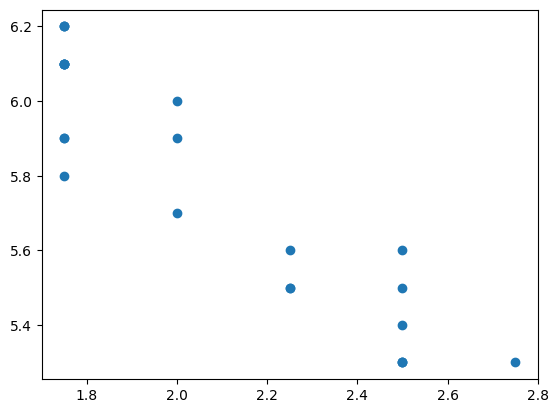

In [57]:
plt.scatter(df['interest_rate'],df['unemployment_rate'])

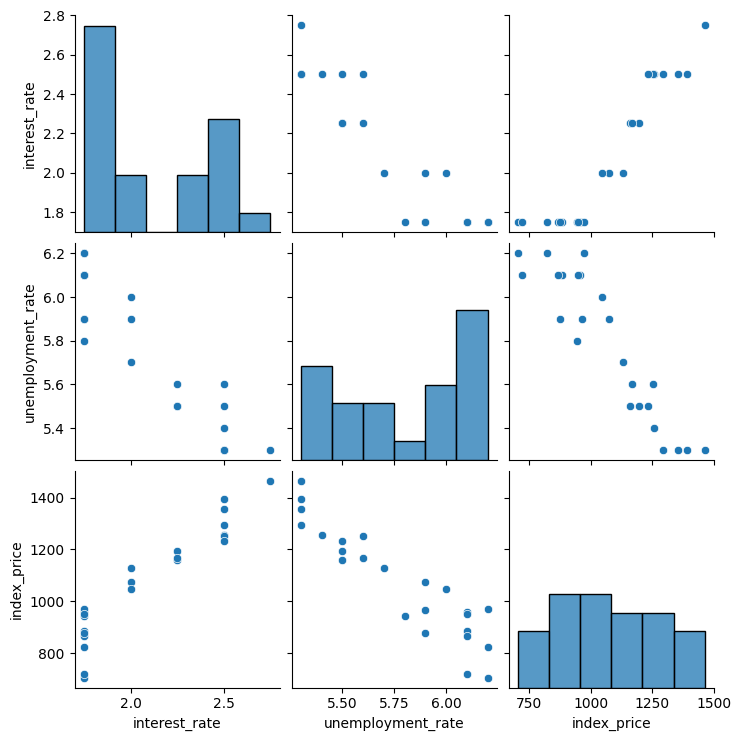

In [58]:
sns.pairplot(df)

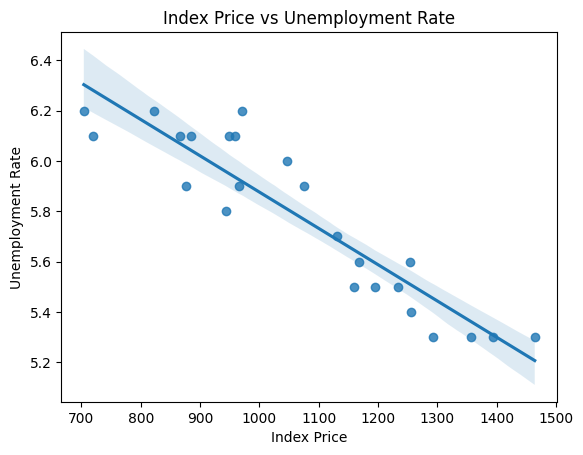

In [59]:
sns.regplot(x='index_price', y='unemployment_rate', data=df)
plt.xlabel('Index Price')
plt.ylabel('Unemployment Rate')
plt.title('Index Price vs Unemployment Rate')
plt.show()

In [60]:
#getting dependent and independent feature
x=df[['interest_rate','unemployment_rate']]
y=df['index_price']

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25,random_state=42)

In [63]:
#standardization
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
xtrain=ss.fit_transform(xtrain)
xtest=ss.transform(xtest)


In [64]:
#regression
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [65]:
regression.fit(xtrain,ytrain)

LinearRegression()

In [66]:
print(regression.coef_)

[  88.27275507 -116.25716066]


In [67]:
from sklearn.model_selection import cross_val_score


In [68]:
validation_score=cross_val_score(regression,xtrain,ytrain,scoring='neg_mean_squared_error',cv=3)

In [70]:
np.mean(validation_score)

np.float64(-5914.828180162388)